In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [40]:
load_dir = r"C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\steps"

dfs = {}

for file_name in os.listdir(load_dir):
    if file_name.endswith(".pkl"):
        file_path = os.path.join(load_dir, file_name)

        df_name = file_name.replace(".pkl", "")
        dfs[df_name] = pd.read_pickle(file_path)

In [41]:
dfs["combined"].head()

,date,user,value
0,2018-11-18,oli,4390
1,2018-11-19,oli,8335
2,2018-11-20,oli,6946
3,2018-11-21,oli,8350
4,2018-11-22,oli,11054


In [42]:
for name, _ in dfs.items():
    print(name)

combined
elina
oli


In [43]:
oli = dfs["oli"]
elina = dfs["elina"]
combined = dfs["combined"]

In [44]:
if oli.shape[0] + elina.shape[0] == combined.shape[0]:
    print(True)
else:
    print(False)

True


In [45]:
def freedman_diaconis(value):
    q1 = np.percentile(value, 25)
    q3 = np.percentile(value, 75)
    iqr = q3-q1
    n = len(value)
    bin_width = 2 * iqr * n **(-1/3)

    return int((np.max(value) - np.min(value)) / bin_width)

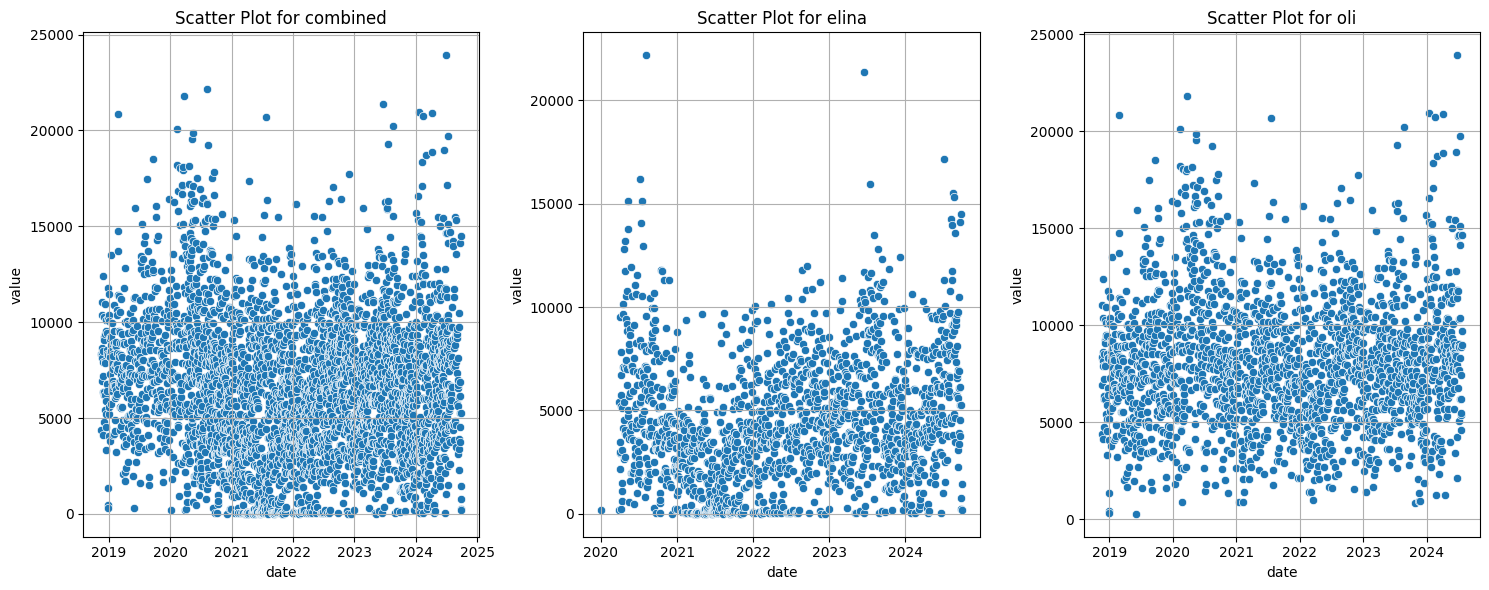

In [46]:
num_dfs = len(dfs)
fig, axes = plt.subplots(1, num_dfs, figsize=(5 * num_dfs, 6)) 

for ax, (name, df) in zip(axes, dfs.items()):
    sns.scatterplot(data = df, x='date', y='value',ax=ax)
    ax.set_title(f'Scatter Plot for {name}')  
    ax.grid(True) 

plt.tight_layout()
plt.show()

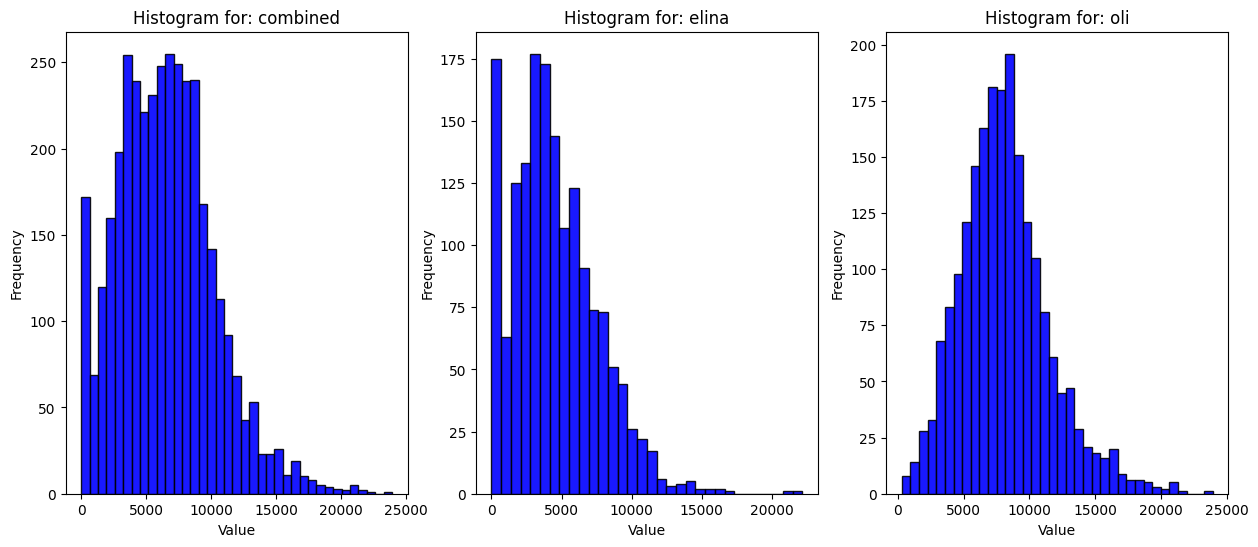

In [47]:
num_dfs = len(dfs)
fig, axes = plt.subplots(1, num_dfs, figsize=(5 * num_dfs, 6)) 

for ax, (name, df) in zip(axes, dfs.items()):
    ax.hist(data=df, x='value', bins=freedman_diaconis(df['value']), color='blue', alpha=0.9, edgecolor='black', axes=ax)
    ax.set_title(f"Histogram for: {name}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.show()    

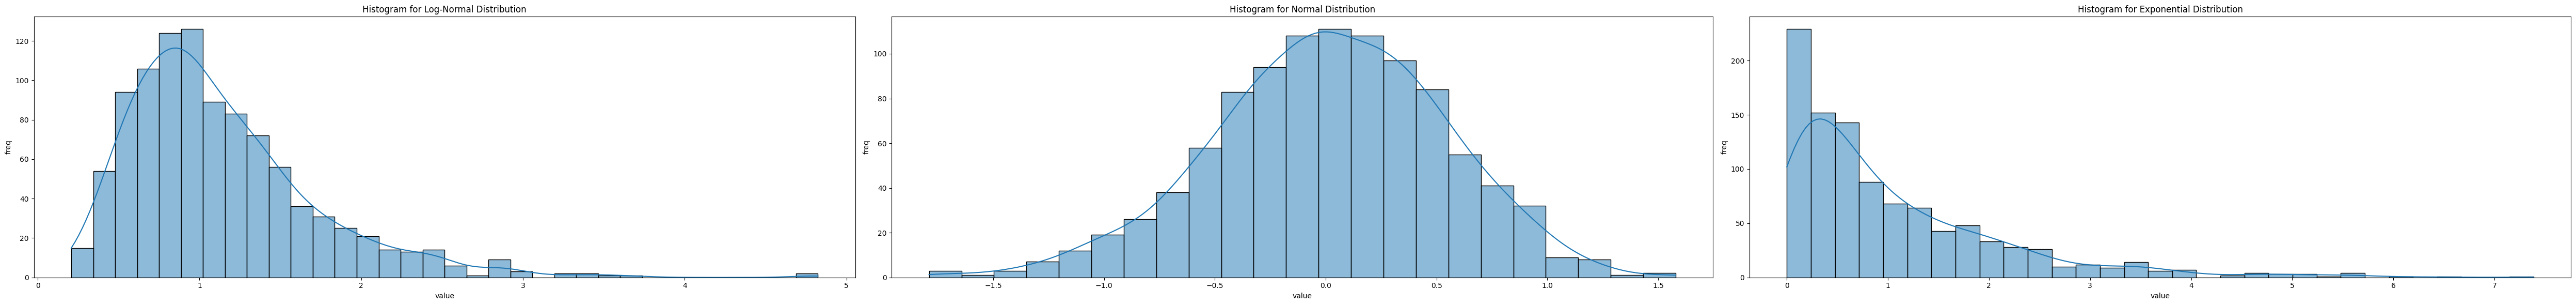

In [55]:
mean = 0
sigma = 0.5
size = 1000
scale = 1
shape = 2
degrees_of_freedom = 5

lognorm = np.random.lognormal(mean=mean, sigma=sigma, size=size)
norm = np.random.normal(loc=mean, scale=sigma, size=size)
exp = np.random.exponential(scale=scale, size=size)

gamma = np.random.gamma(shape=2, scale=scale, size=size)
weibull = np.random.weibull(a=shape, size=size)*scale
chi = np.random.chisquare(df=degrees_of_freedom, size=size) 
khi = np.random.chisquare(df=degrees_of_freedom, size=size) 
fhi = np.random.chisquare(df=degrees_of_freedom, size=size) 
ghi = np.random.chisquare(df=degrees_of_freedom, size=size) 
mhi = np.random.chisquare(df=degrees_of_freedom, size=size) 

dists = {'Log-Normal':lognorm, 'Normal':norm, 'Exponential': exp, 'Gamme':gamma, 'Weibull':weibull, 'Chi':chi, 'khi':khi, 'fhi':fhi, 'ghi':ghi, 'mhi':mhi}

num_dfs = len(dists)
fig, axes = plt.subplots(1, 3, figsize=(5 * num_dfs, 6)) 
axes = axes.flatten()


for ax, (name, dist) in zip(axes, dists.items()):
    sns.histplot(data=dist, bins=freedman_diaconis(dist), kde=True, ax=ax)
    ax.set_xlabel('value')
    ax.set_ylabel('freq')
    ax.set_title(f"Histogram for {name} Distribution")

plt.tight_layout()
plt.show()


TypeError: 'Axes' object is not iterable

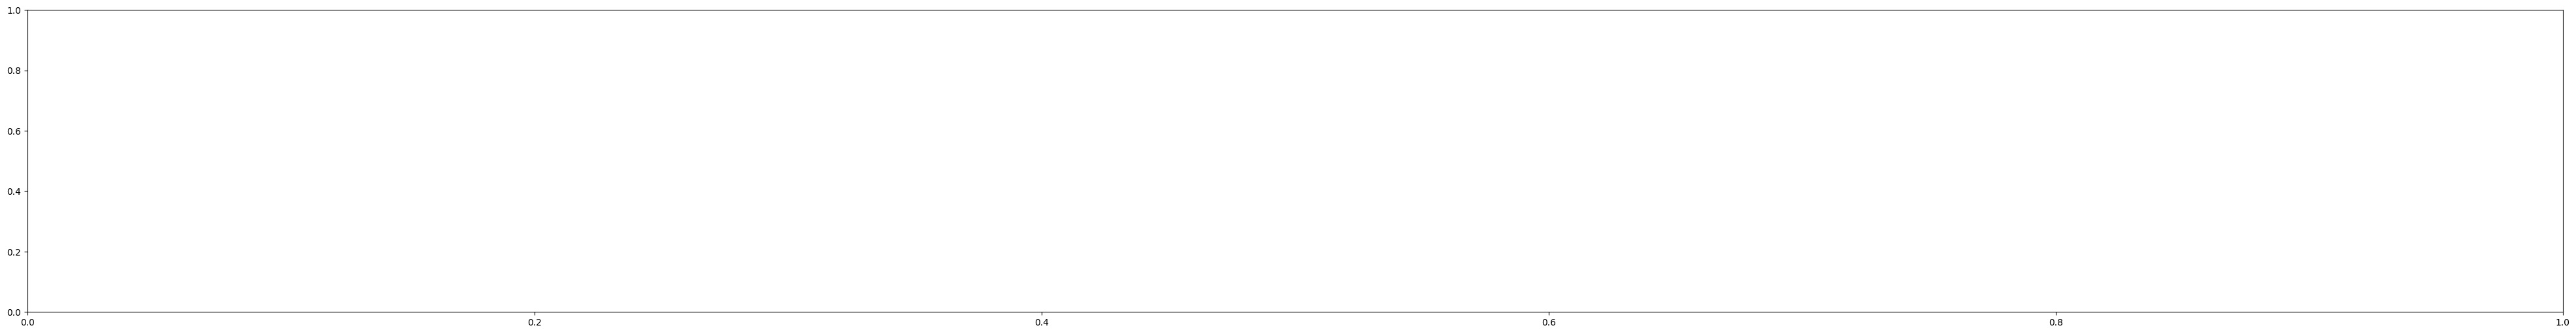

In [58]:
mean = 0
sigma = 0.5
size = 1000
scale = 1
shape = 2
degrees_of_freedom = 5

lognorm = np.random.lognormal(mean=mean, sigma=sigma, size=size)
norm = np.random.normal(loc=mean, scale=sigma, size=size)
exp = np.random.exponential(scale=scale, size=size)

gamma = np.random.gamma(shape=2, scale=scale, size=size)
weibull = np.random.weibull(a=shape, size=size)*scale
chi = np.random.chisquare(df=degrees_of_freedom, size=size) 
khi = np.random.chisquare(df=degrees_of_freedom, size=size) 
fhi = np.random.chisquare(df=degrees_of_freedom, size=size) 
ghi = np.random.chisquare(df=degrees_of_freedom, size=size) 
mhi = np.random.chisquare(df=degrees_of_freedom, size=size) 

dists = {'Log-Normal':lognorm, 'Normal':norm, 'Exponential': exp, 'Gamme':gamma, 'Weibull':weibull, 'Chi':chi, 'khi':khi, 'fhi':fhi, 'ghi':ghi, 'mhi':mhi}

rows = 0
cols = 1
row_counter = 2
num_dfs = len(dists)

for i in range(len(dists)):
    
    if i <= 3:
        fig, axes = plt.subplots(1, cols, figsize=(5 * num_dfs, 6)) 
        #axes = axes.flatten()

        for ax, (name, dist) in zip(axes, dists.items()):
            sns.histplot(data=dist, bins=freedman_diaconis(dist), kde=True, ax=ax)
            ax.set_xlabel('value')
            ax.set_ylabel('freq')
            ax.set_title(f"Histogram for {name} Distribution")

        plt.tight_layout()
        plt.show()

    else:
        rows = row_counter
        cols = 3
        
        if (i - 3) % 3 == 0:
            row_counter += 1
            fig, axes = plt.subplots(row_counter, cols, figsize=(5 * num_dfs, 6))
            #axes = axes.flatten()

            for ax, (name, dist) in zip(axes, dists.items()):
                sns.histplot(data=dist, bins=freedman_diaconis(dist), kde=True, ax=ax)
                ax.set_xlabel('value')
                ax.set_ylabel('freq')
                ax.set_title(f"Histogram for {name} Distribution")

            plt.tight_layout()
            plt.show()

In [53]:
rows = []
cols = []
idx = []

row_counter = 2

for i in range(1, 16):
    
    if i <= 3:
        rows.append(1)
        cols.append(i)
    else:
        rows.append(row_counter)
        cols.append(3)
        
        if (i - 3) % 3 == 0:
            row_counter += 1

print(f"idx: {idx}\nrows: {rows}\ncols: {cols}")

idx: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
rows: [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5]
cols: [1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


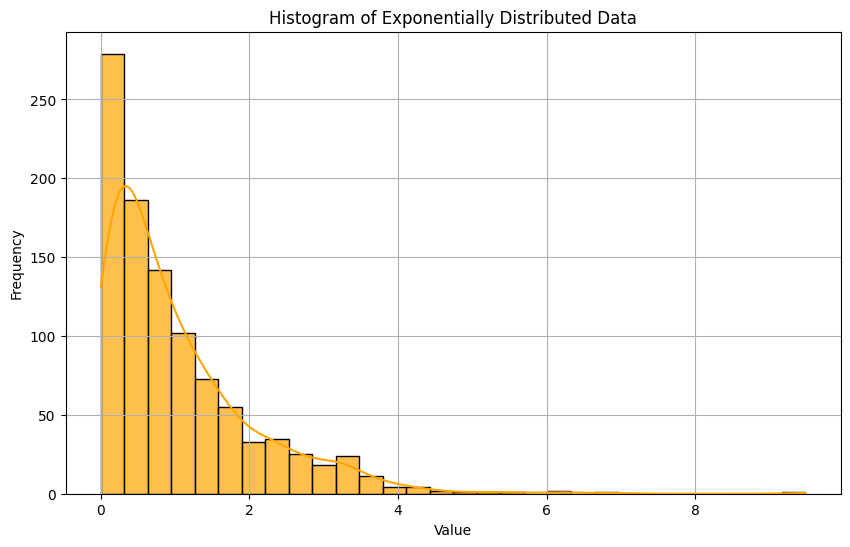

In [64]:
scale = 1           # Mean (1/λ)
num_samples = 1000  # Number of samples to generate

# Generate exponentially distributed data
data = np.random.exponential(scale=scale, size=num_samples)

# Visualize the generated data
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=True, color='orange', alpha=0.7)
plt.title("Histogram of Exponentially Distributed Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [156]:
45000/12

3750.0